# ANÁLISIS EXPLORATORIO Y TRANSFORMACIÓN DE DATOS

### Librerias y Carga de datos


In [36]:
!pip install pandas numpy matplotlib seaborn plotly
!pip install scikit-learn scipy
!pip install missingno # Para visualización de datos faltantes
!pip install sweetviz # Para reportes automáticos de EDA
!pip install pandas-profiling # Para perfilado automático de datos
!pip install imbalanced-learn # Para manejo de datos desbalanceados
!pip install openpyxl # Para leer archivos Excel si es necesario
!pip install wordcloud # Para visualización de nubes de palabras


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the s

In [ ]:
# Importación de librerías esenciales para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
import unicodedata
from wordcloud import WordCloud
from plotly.subplots import make_subplots
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Para análisis estadístico
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Para visualización de datos faltantes
# import missingno as msno

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configuración de warnings
import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_excel('../../data.xlsx')

print(f"Datos originales:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

# Filtrar solo casos críticos
df = df[df['Hallazgo Crítico'] == 1]

print(f"\n{'='*50}")
print(f"Después de filtrar por casos críticos:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

print(f"\nValores nulos después del filtrado:")
print(df.isnull().sum())


Datos originales:
  - Filas: 3984
  - Columnas: 11

Después de filtrar por casos críticos:
  - Filas: 897
  - Columnas: 11

Valores nulos después del filtrado:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     3
Hallazgos                          1
Opinión                            2
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [39]:
# Revisar registros con valores nulos en columnas clave antes de limpiar
print("\nRegistros con Datos Clínicos nulo:")
display(df[df['Datos Clínicos'].isnull()])
print("\nRegistro con Hallazgos nulo:")
display(df[df['Hallazgos'].isnull()])
print("\nRegistros con Opinión nulo:")
display(df[df['Opinión'].isnull()])


Registros con Datos Clínicos nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
3704,2025-01-07 20:06:25,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,"961.5 DLP (mGy - cm)\nEn equipo multidetector,...",NaN,Cambios postquirúrgicos por orificios de trépa...,Hematoma subdural fronto-temporoparietal izqui...,0,0,1,0.0
3828,2025-06-09 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,1279.55 DLP (mGy - cm)\nMedio de contraste: NO...,NaN,En este control se observa nueva pérdida difus...,Pérdida difusa de la diferenciación entre sust...,0,0,1,0.0
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0



Registro con Hallazgos nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0



Registros con Opinión nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
3805,2025-06-15 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,2674.8 DLP (mGy - cm)\nMedio de contraste: NO ...,POLITRAUMA POR ACCIDENTE DE TRANSITO -.,Hematoma epidural frontal izquierdo con espeso...,NaN,0,0,1,0.0
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0


In [40]:
# Limpieza recomendada para entrenamiento de modelos
df['Datos Clínicos'] = df['Datos Clínicos'].fillna('NR')  # Solo si Hallazgos y Opinión están presentes
df = df.dropna(subset=['Hallazgos', 'Opinión'])  # Elimina registros sin texto o sin etiqueta
print('Registros restantes tras limpieza:')
print(df.shape)
print('Valores nulos por columna:')
print(df.isnull().sum())

Registros restantes tras limpieza:
(895, 11)
Valores nulos por columna:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [41]:
df['Datos Clínicos'] = df['Datos Clínicos'].fillna('NR')
df['Técnica'] = df['Técnica'].fillna('NR')
df['Estudio Normal'] = df['Estudio Normal'].fillna(0)
# Eliminamos las filas con nulos en 'Hallazgos' o 'Opinión'
df = df.dropna(subset=['Hallazgos', 'Opinión'])
# Verificar valores nulos después de la limpieza
print(df.isnull().sum())

Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [42]:
# Columnas de texto no estructurado a normalizar
text_columns = ['Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión']

for col in text_columns:
    # Convertir a string (por si hay valores numéricos o NaN)
    df[col] = df[col].astype(str)
    
    # Convertir a minúsculas
    df[col] = df[col].str.lower()
    
    # Eliminar espacios extra al inicio y final
    df[col] = df[col].str.strip()
    
    # Reemplazar múltiples espacios por un solo espacio
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
    # Normalizar puntuación: agregar espacio después de puntos, comas, etc.
    df[col] = df[col].str.replace(r'([.,:;!?])', r'\1 ', regex=True)
    
    # Eliminar espacios extra nuevamente
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

print("Normalización de texto no estructurado completada")

Normalización de texto no estructurado completada


In [43]:
for col in ['Modalidad', 'Estudio', 'Técnica', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Modalidad value counts:
Modalidad
CT    895
Name: count, dtype: int64

Estudio value counts:
Estudio
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                        382
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE                                        278
 TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                       216
TOMOGRAFIA COMPUTADA DE CRANEO                                                 4
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE YCON CONTRASTE                           4
TOMOGRAFÍA COMPUTADA DE CRÁNEO CON CONTRASTE                                   3
TOMOGRAFIA COMPUTADA DE CRANEO Y COLUMNA CERVICAL SIMPLE                       1
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE CON ANGIOTAC DE ARTERIAS CEREBRALES      1
TOMOGRAFIA COMPUTADA DE CRANEO Simple                                          1
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE Y CON CONTRASTE                          1
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE.                                         1
COMPUTA

In [44]:
def remove_accents(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_estudio(value):
    v = str(value).lower().strip()
    v = remove_accents(v)
    v = re.sub(r'\s+', ' ', v)
    v = v.replace('.', '')  # Elimina puntos finales
    # Angiotac (debe ir antes de "simple")
    if 'angiotac' in v:
        return 'tomografia computada de craneo simple con angiotac de arterias cerebrales'
    # Agrupar variantes de "simple"
    if re.search(r'tomografia computada de craneo simple', v) or \
        re.search(r'tomografia computada de craneo simpl', v) or \
        re.search(r'tomografia computada de craneo$', v) or \
        re.search(r'tomografia computada de crane$', v) or \
        re.search(r'tomografia computada de craneo simplev', v) or\
        re.search(r'tomografia axial computarizada de craneo simple dentro de limites normales', v) or\
        re.search(r'trauma craneoencefalico, cefalea y emesis', v) or\
        re.search(r'computada de craneo simple', v):
            return 'tomografia computada de craneo simple'
    # Agrupar variantes de "con contraste"
    if 'contraste' in v:
        return 'tomografia computada de craneo con contraste'
    # Agrupar columna cervical
    if 'columna cervical' in v:
        return 'tomografia computada de craneo y columna cervical simple'
    # TAC de recien nacidos
    if 'recien nacidos' in v:
        return 'tac de craneo simple recien nacidos'
    # Trauma, cefalea, emesis (caso único)
    if 'trauma' in v or 'cefalea' in v or 'emesis' in v:
        return v  # Mantener tal cual, es un caso único
    # Si nada coincide, devolver el valor normalizado
    return v

df['Estudio'] = df['Estudio'].apply(normalize_estudio)
print(df['Estudio'].value_counts())
# Guardar el DataFrame limpio
df.to_excel('../../data_cleaned.xlsx', index=False)
print("Archivo normalizado guardado como 'data_cleaned.xlsx'")

Estudio
tomografia computada de craneo simple                                        890
tomografia computada de craneo con contraste                                   3
tomografia computada de craneo y columna cervical simple                       1
tomografia computada de craneo simple con angiotac de arterias cerebrales      1
Name: count, dtype: int64
Archivo normalizado guardado como 'data_cleaned.xlsx'


In [45]:
# Verificar distribución de valores binarios
print("Distribución de Hallazgo Crítico:")
print(df['Hallazgo Crítico'].value_counts())

print("\nDistribución de Estudio Normal:")
print(df['Estudio Normal'].value_counts())

print("\nDistribución de Reporte estructurado:")
print(df['Reporte estructurado'].value_counts())

print("\nDistribución de Estudio Complementario Sugerido:")
print(df['Estudio Complementario Sugerido'].value_counts())

Distribución de Hallazgo Crítico:
Hallazgo Crítico
1    895
Name: count, dtype: int64

Distribución de Estudio Normal:
Estudio Normal
0.0    895
Name: count, dtype: int64

Distribución de Reporte estructurado:
Reporte estructurado
0    624
1    271
Name: count, dtype: int64

Distribución de Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    848
1     47
Name: count, dtype: int64



Reporte estructurado:
Reporte estructurado
0    624
1    271
Name: count, dtype: int64
Proporción de 1: 0.3027932960893855

Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    848
1     47
Name: count, dtype: int64
Proporción de 1: 0.05251396648044693


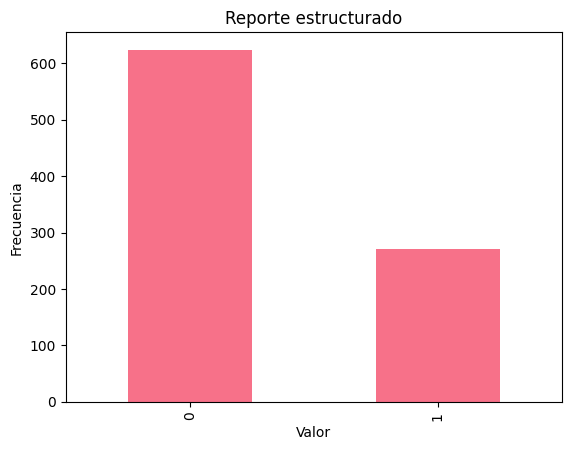

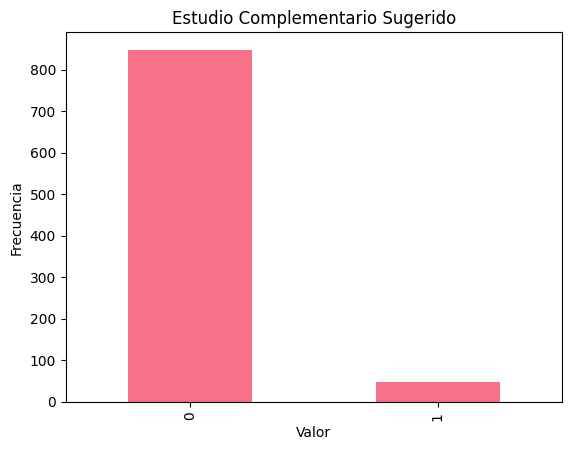

In [46]:
binary_cols = ['Reporte estructurado', 'Estudio Complementario Sugerido']

for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("Proporción de 1:", df[col].mean())

for col in binary_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.show()

In [47]:
# Muestra aleatoria de hallazgos y opiniones
print(df['Hallazgos'].sample(20, random_state=1))
print(df['Opinión'].sample(20, random_state=1))

all_text = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words = re.findall(r'\b\w+\b', all_text)
counter = Counter(words)
print(counter.most_common(50))  # 50 palabras más frecuentes

vectorizer = CountVectorizer(ngram_range=(2,3), max_features=50)
X = vectorizer.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
ngram_freq = sorted(zip(ngrams, counts), key=lambda x: -x[1])
print(ngram_freq)

3622    signos de sangrado. hematoma subdural: no. hem...
358     en la región frontal derecha se observa un hem...
3462    hipodensidad mal definida con pérdida de difer...
804     signos de sangrado. hematoma subdural: no. hem...
62      prominencia surcos y cisuras por pérdida volum...
3784    trayecto de proyectil de arma de fuego que ing...
3769    se evidencian al menos 7 masas hiperdensas het...
1058    signos de sangrado. hematoma subdural: no. hem...
48      signos de sangrado. hematoma subdural: si, hem...
3451    fractura no desplazada del hueso parietal dere...
3405    cambios postquirúrgicos de craneotomía frontal...
1791    hematoma subdural hemisférico izquierdo de has...
3498    cambios post quirúrgicos de craniotomía fronto...
3964    hematoma epidural frontal bilateral, con groso...
3014    artefacto por presencia de material metálico d...
3919    colecciones subdurales homogéneamente hipodens...
3954    signos de sangrado. hematoma subdural: no. hem...
2558    signos

TOP 5 PALABRAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)
cerebral             1070
normal               1045
hematoma             1021
media                974
frontal              830

TOP 20 N-GRAMAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)
línea media                         752
sistema ventricular                 740
hemorragia subaracnoidea            558
senos paranasales                   537
fosa posterior                      415
ventrículo lateral                  379
espacio subaracnoideo               378
hematoma subdural                   370
parénquima cerebral                 354
efecto masa                         340
sustancia blanca                    335
estructuras línea                   328
estructuras línea media             328
surcos espacio                      286
signos isquemia                     285
isquemia aguda                      282
signos isquemia aguda               282
surcos espacio subaracnoideo        268
tejidos blandos               

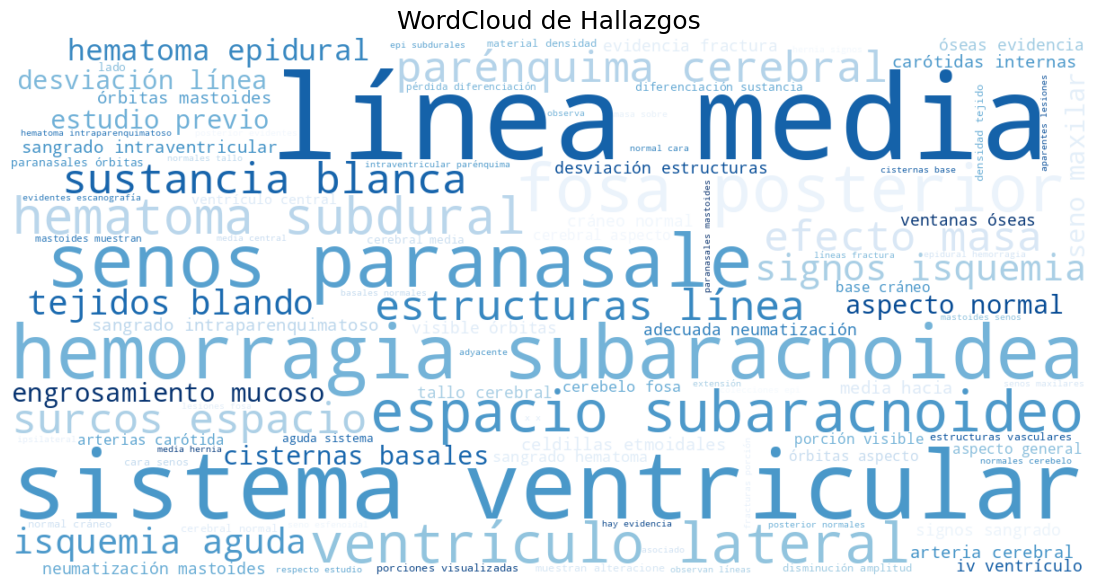

TOP 5 PALABRAS MÁS FRECUENTES EN OPINIONES (sin conectores)
cerebral             423
hematoma             418
hemorragia           334
subaracnoidea        269
media                265

TOP 20 N-GRAMAS MÁS FRECUENTES EN OPINIONES (sin conectores)
hemorragia subaracnoidea            268
arteria cerebral                    170
hematoma subdural                   163
cerebral media                      142
arteria cerebral media              138
sistema ventricular                 137
hernia subfalcina                   133
edema cerebral                      125
hematoma intraparenquimatoso        121
efecto masa                         120
línea media                         110
territorio arteria                  98
territorio arteria cerebral         95
estudio previo                      85
transformación hemorrágica          83
cerebral difuso                     82
evento isquémico                    82
edema cerebral difuso               81
hematoma epidural                   76
d

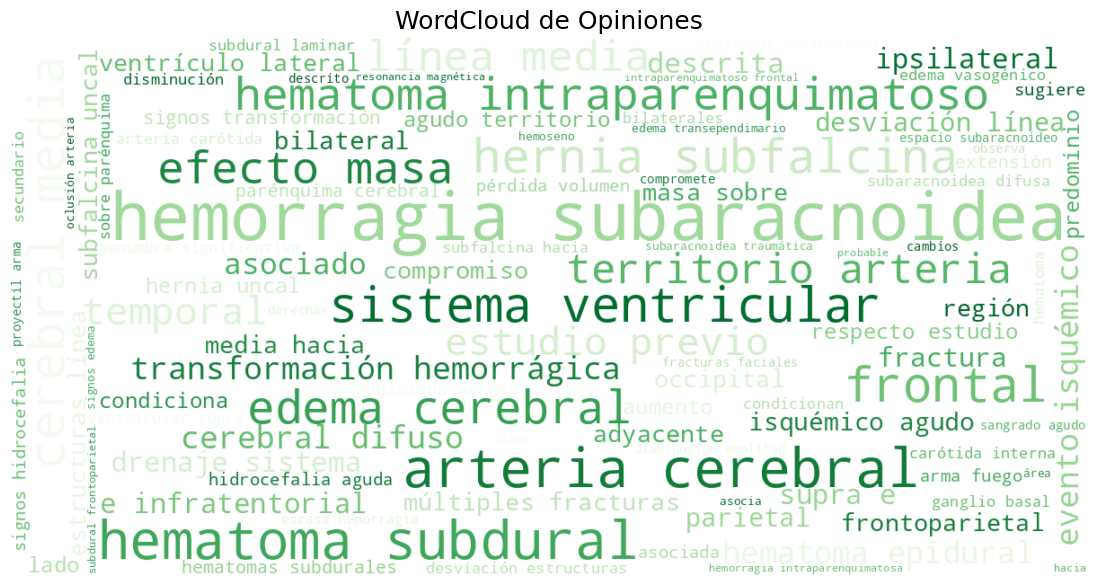

In [48]:
stopwords_es = [
    'de','la','y','el','en','del','con','se','las','los','por','para','al','lo','un','una','es','su','sus','que','a','o','sin','no','izquierdo','izquierda','derecha','derecho','mm'
]

# HALLAZGOS
all_text_h = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words_h = re.findall(r'\b\w+\b', all_text_h)
words_h_filtradas = [w for w in words_h if w not in stopwords_es]
counter_h = Counter(words_h_filtradas)
print("TOP 5 PALABRAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)")
for palabra, freq in counter_h.most_common(5):
    print(f"{palabra:<20} {freq}")

vectorizer_h = CountVectorizer(ngram_range=(2,3), max_features=20, stop_words=stopwords_es)
X_h = vectorizer_h.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams_h = vectorizer_h.get_feature_names_out()
counts_h = X_h.sum(axis=0).A1
ngram_freq_h = sorted(zip(ngrams_h, counts_h), key=lambda x: -x[1])
print("\nTOP 20 N-GRAMAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)")
for ngrama, freq in ngram_freq_h:
    print(f"{ngrama:<35} {freq}")

corpus_hallazgos = ' '.join(words_h_filtradas)
wc_hallazgos = WordCloud(
    width=1200, height=600, background_color='white',
    stopwords=stopwords_es, colormap='Blues', max_words=100
).generate(corpus_hallazgos)
plt.figure(figsize=(14, 7))
plt.imshow(wc_hallazgos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud de Hallazgos', fontsize=18)
plt.show()

# OPINIONES
all_text_o = ' '.join(df['Opinión'].dropna().astype(str).tolist()).lower()
words_o = re.findall(r'\b\w+\b', all_text_o)
words_o_filtradas = [w for w in words_o if w not in stopwords_es]
counter_o = Counter(words_o_filtradas)
print("TOP 5 PALABRAS MÁS FRECUENTES EN OPINIONES (sin conectores)")
for palabra, freq in counter_o.most_common(5):
    print(f"{palabra:<20} {freq}")

vectorizer_o = CountVectorizer(ngram_range=(2,3), max_features=20, stop_words=stopwords_es)
X_o = vectorizer_o.fit_transform(df['Opinión'].dropna().astype(str).str.lower())
ngrams_o = vectorizer_o.get_feature_names_out()
counts_o = X_o.sum(axis=0).A1
ngram_freq_o = sorted(zip(ngrams_o, counts_o), key=lambda x: -x[1])
print("\nTOP 20 N-GRAMAS MÁS FRECUENTES EN OPINIONES (sin conectores)")
for ngrama, freq in ngram_freq_o:
    print(f"{ngrama:<35} {freq}")

corpus_opiniones = ' '.join(words_o_filtradas)
wc_opiniones = WordCloud(
    width=1200, height=600, background_color='white',
    stopwords=stopwords_es, colormap='Greens', max_words=100
).generate(corpus_opiniones)
plt.figure(figsize=(14, 7))
plt.imshow(wc_opiniones, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud de Opiniones', fontsize=18)
plt.show()

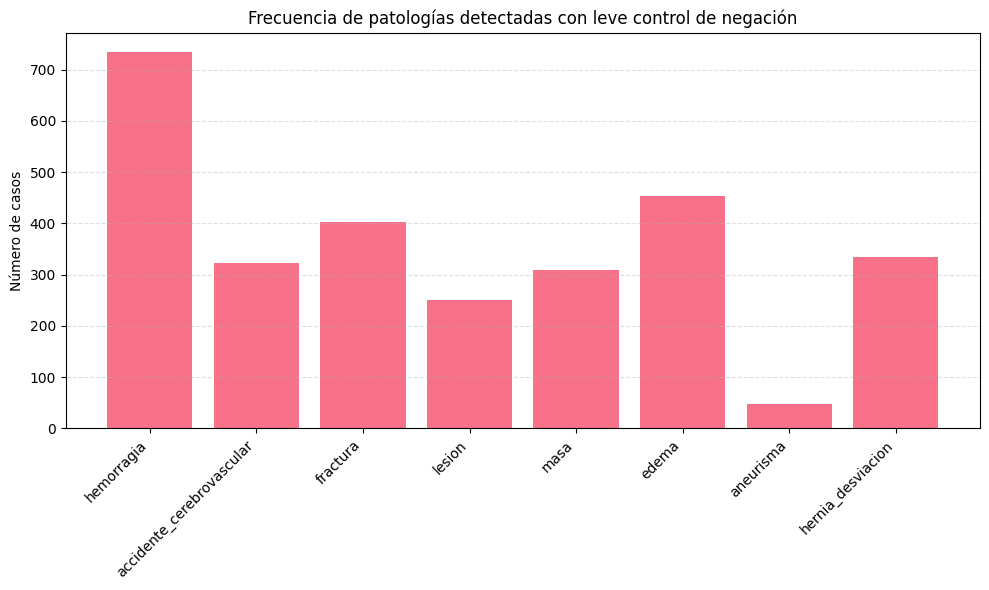

{'hemorragia': 735, 'accidente_cerebrovascular': 322, 'fractura': 402, 'lesion': 250, 'masa': 310, 'edema': 453, 'aneurisma': 48, 'hernia_desviacion': 335}


In [49]:
# 1. Diccionario clínico: patologías / sinónimos
PATOLOGIAS = {
    "hemorragia": [
        r"hemorragia", r"hematoma", r"sangrado",
        r"coleccion hematic", r"hematocele"
    ],
    "accidente_cerebrovascular": [
        r"infarto", r"isquemia", r"ictus", r"acv",
        r"evento cerebrovascular", r"hipodensidad sugestiva de isquemia"
    ],
    "fractura": [
        r"fractura", r"linea de fractura", r"trazo de fractura"
    ],
    "lesion": [
        r"lesion", r"lesiones", r"area lesion", r"contusion"
    ],
    "masa": [
        r"masa", r"lesion ocupante de espacio", r"loe", r"tumor",
        r"neoplasia", r"lesion nodular"
    ],
    "edema": [
        r"edema", r"hipodensidad difusa compatible con edema"
    ],
    "aneurisma": [
        r"aneurisma", r"dilatacion aneurismatica"
    ],
    "hernia_desviacion": [
        r"hernia", r"herniacion",
        r"desviaci[oó]n de la l[ií]nea media", r"desviacion de la linea media"
    ]
}
# 2. Negaciones robustas
NEGACIONES = [
    r"no se observa", r"no se evidencia", r"no hay",
    r"sin evidencia de", r"sin signos de", r"ausencia de",
    r"negativa para", r"niega", r"descarta"
]

# 3. Función para detección
def detectar_patologia(texto, patrones_pos, patrones_neg, ventana=60):
    if not isinstance(texto, str):
        return False

    texto = texto.lower()

    # Buscar patrones positivos
    for pos in patrones_pos:
        for match in re.finditer(pos, texto):
            start = match.start()

            # Revisar si hay negaciones antes dentro de una ventana contextual
            ventana_inicio = max(0, start - ventana)
            contexto = texto[ventana_inicio:start]

            if not any(re.search(neg, contexto) for neg in patrones_neg):
                return True

    return False

# 4. Aplicación y conteo
resultados = {}

for nombre, patrones in PATOLOGIAS.items():
    count = df["Hallazgos"].apply(
        lambda x: detectar_patologia(x, patrones, NEGACIONES)
    ).sum()

    resultados[nombre] = count

# 5. Visualización 
plt.figure(figsize=(10, 6))
plt.bar(resultados.keys(), resultados.values())
plt.ylabel("Número de casos")
plt.title("Frecuencia de patologías detectadas con leve control de negación")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print(resultados)

## Selección de categorías diagnósticas predominantes

Tras el análisis exploratorio de frecuencias y relevancia clínica, **consideramos como opción predominante** las siguientes categorías para el modelo de clasificación automática:

- hemorragia /  hematoma cerebral
- accidente cerebrovascular
- fractura
- masa

Esto por su frecuencia, relevancia clínica y claridad en los reportes. Se crearán variables binarias para cada una, que servirán como etiquetas principales en el entrenamiento y validación del modelo.

In [50]:
def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """
    Detecta patologías con análisis de contexto robusto.
    
    Args:
        texto: Texto completo del hallazgo
        keywords_positivos: Lista de palabras clave ordenada por especificidad
        keywords_negativos: Lista de términos de antigüedad/cronicidad
    
    Returns:
        1 si detecta patología aguda y presente, 0 en caso contrario
    """
    if not isinstance(texto, str):
        return 0
    
    texto = texto.lower()
    
    keywords_negativos = keywords_negativos or [
        'antiguo', 'antigua', 'antiguos', 'antiguas',
        'cronico', 'cronica', 'cronicos', 'cronicas',
        'crónico', 'crónica', 'crónicos', 'crónicas',
        'viejo', 'vieja', 'viejos', 'viejas',
        'residual', 'residuales',
        'secuela', 'secuelar', 'secuelas',
        'previo', 'previa', 'previos', 'previas',
        'conocido', 'conocida', 'conocidos', 'conocidas',
        'ya descrito', 'ya descritos', 'ya descrita', 'ya descritas',
        'ya visualizado', 'ya visualizada', 'ya visualizados', 'ya visualizadas',
        'sin cambios', 'estable', 'estables',
        'resolucion', 'resolución'
    ]
    
    negaciones_contextuales = [
        'sin', 'descarta', 'descartado', 'descartada', 'descartados', 'descartadas',
        'negativo', 'negativa', 'negativos', 'negativas',
        'ausencia', 'ausencia de', 'ausente', 'ausentes',
        'sin evidencia', 'sin evidencia de',
        'sin signos', 'sin signos de',
        'sin signos indirectos', 'sin signos indirectos de',
        'no se observa', 'no se observan',
        'no se evidencia', 'no se evidencian',
        'no se identifica', 'no se identifican',
        'libre de', 'negativo para', 'negativa para'
    ]
    
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    
    for oracion in oraciones:
        oracion = oracion.strip()
        
        keyword_encontrada = None
        for kw in keywords_ordenadas:
            if kw in oracion:
                keyword_encontrada = kw
                break
        
        if not keyword_encontrada:
            continue
        
        patron_keyword_no = re.escape(keyword_encontrada) + r'\s*:\s*no\b'
        if re.search(patron_keyword_no, oracion):
            continue
        
        patron_estructurado = re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b'
        if re.search(patron_estructurado, oracion):
            continue
        
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        
        patron_sin_hallazgos = r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada)
        if re.search(patron_sin_hallazgos, oracion):
            continue
        
        if any(ant in oracion for ant in keywords_negativos):
            continue
        
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion and keyword_encontrada in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        
        return 1
    
    return 0


# Cargar datos
df = pd.read_excel('../../data_cleaned.xlsx')

# Mantener solo columnas originales + las 4 nuevas
columnas_originales = ['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 
                       'Datos Clínicos', 'Hallazgos', 'Opinión', 
                       'Reporte estructurado', 'Estudio Complementario Sugerido', 
                       'Hallazgo Crítico', 'Estudio Normal']

# Definir keywords
keywords_hemorragia = [
    'hemorragia subaracnoidea', 'hemorragia subaracnoideas',
    'hematoma subdural', 'hematoma epidural',
    'sangrado intraparenquimatoso', 'sangrado intraventricular',
    'hemorragia intraparenquimatosa', 'hemorragia intraventricular',
    'hemorragia interhemisferica', 'hemorragia parenquimatosa',
    'foco hemorragico', 'focos hemorragicos',
    'foco de hemorragia', 'focos de hemorragia',
    'hemorragia', 'hemorragico', 'hemorragica', 'hemorragicos', 'hemorragicas',
    'hematoma', 'hematomas',
    'sangrado', 'sangrados'
]

keywords_acv_isquemico = [
    'infarto cerebral', 'infarto lacunar', 'infartos lacunares',
    'evento isquemico', 'evento cerebrovascular',
    'area de isquemia', 'areas de isquemia',
    'zona de isquemia', 'zonas de isquemia',
    'evento vascular cerebral',
    'territorio vascular',
    'hipodensidad cortical', 'hipodensidad subcortical',
    'infarto', 'infartos',
    'isquemia', 'isquemias',
    'isquemico', 'isquemica', 'isquemicos', 'isquemicas',
    'ictus',
    'acv'
]

keywords_fractura = [
    'fractura craneal', 'fractura de craneo',
    'fractura lineal', 'fractura deprimida',
    'fractura conminuta', 'fractura hundimiento',
    'fractura', 'fracturas'
]

keywords_masa = [
    'lesion ocupante', 'lesiones ocupantes',
    'efecto de masa',
    'lesion tumoral', 'proceso expansivo',
    'proceso ocupante',
    'masa', 'masas',
    'tumor', 'tumores', 'tumoral', 'tumorales',
    'neoplasia', 'neoplasias', 'neoplasica', 'neoplasico'
]

# Aplicar detección solo a las 4 categorías
df['hemorragia'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_hemorragia)
)

df['acv'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_acv_isquemico)
)

df['fractura'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_fractura)
)

df['masa'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_masa)
)

# Mantener solo columnas necesarias
columnas_finales = columnas_originales + ['hemorragia', 'acv', 'fractura', 'masa']
df_final = df[columnas_finales]

df_final.to_excel('../../data_with_diagnostics_clean.xlsx', index=False)

print(f"Hemorragia: {df_final['hemorragia'].sum()} casos")
print(f"ACV isquémico: {df_final['acv'].sum()} casos")
print(f"Fractura: {df_final['fractura'].sum()} casos")
print(f"Masa: {df_final['masa'].sum()} casos")
print(f"\nArchivo guardado: {df_final.shape[0]} filas, {df_final.shape[1]} columnas")

for col in ['hemorragia', 'acv', 'fractura', 'masa']:
    print(f"\nEjemplos donde {col}=1:")
    display(df_final[df_final[col]==1][['Hallazgos', col, 'Hallazgo Crítico']].sample(5, random_state=1))

Hemorragia: 719 casos
ACV isquémico: 397 casos
Fractura: 380 casos
Masa: 210 casos

Archivo guardado: 895 filas, 15 columnas

Ejemplos donde hemorragia=1:


,Hallazgos,hemorragia,Hallazgo Crítico
65,signos de sangrado. hematoma subdural: no. hem...,1,1
66,"signos de sangrado. hematoma subdural: sí, fro...",1,1
230,hemorragia intraparenquimatosa: hemorragia fro...,1,1
785,hematoma intraparenquimatoso agudo en la regió...,1,1
9,signos de sangrado. hematoma subdural: hemisfé...,1,1



Ejemplos donde acv=1:


,Hallazgos,acv,Hallazgo Crítico
298,signos de sangrado. hematoma subdural: no. hem...,1,1
811,"signos de sangrado. hematoma subdural: si, int...",1,1
506,"signos de sangrado. hematoma subdural: si, fro...",1,1
561,hipodensidades que compromete la sustancia bla...,1,1
582,"signos de sangrado. hematoma subdural: si, tem...",1,1



Ejemplos donde fractura=1:


,Hallazgos,fractura,Hallazgo Crítico
492,signos de sangrado. hematoma subdural: no. hem...,1,1
286,signos de sangrado. hematoma subdural: parieta...,1,1
584,"laceración transfixiante intraparenquimatosa, ...",1,1
294,signos de sangrado. hematoma subdural: hematom...,1,1
443,herida por proyectil de arma de fuego que cond...,1,1



Ejemplos donde masa=1:


,Hallazgos,masa,Hallazgo Crítico
223,"hematoma subdural heterogéneo, hemisférico izq...",1,1
795,hematoma parenquimatoso frontoparietal derecho...,1,1
259,signos de sangrado. hematoma subdural: no. hem...,1,1
885,hematoma subdural holohemisférico derecho dens...,1,1
190,cambios de craneotomía frontoparietal izquierd...,1,1


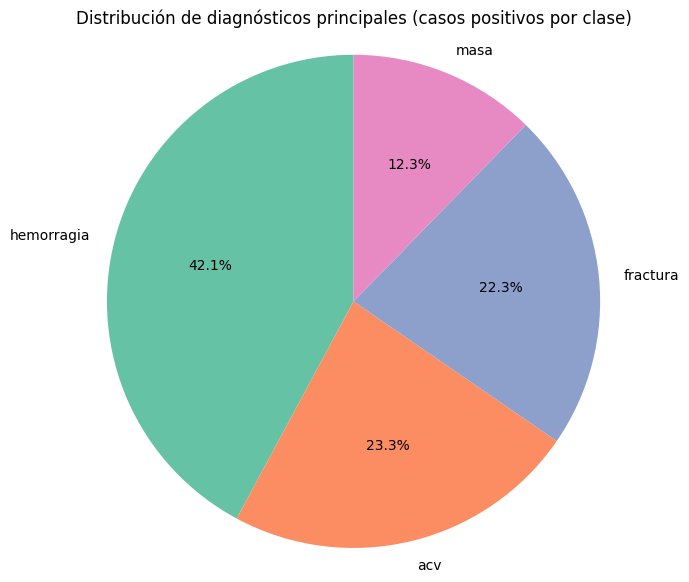

In [51]:
# Leer el archivo con las 4 columnas binarias
df = pd.read_excel('../../data_with_diagnostics_clean.xlsx')

# Contar positivos por clase
labels = ['hemorragia', 'acv', 'fractura', 'masa']
counts = [df[col].sum() for col in labels]

# Gráfica de torta
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Distribución de diagnósticos principales (casos positivos por clase)')
plt.axis('equal')
plt.show()

## Modelo Baseline: Regresión Logística para Clasificación de Patologías

### Resumen del Enfoque

**Problema:** Clasificación binaria de patologías detectadas en reportes radiológicos (hemorragia, ACV, fractura, masa)

### Entrenamiento de Modelos para las 4 Patologías

Se entrena regresión logística en cada patología por separado. Cada modelo aprende 
qué palabras/patrones predicen esa enfermedad específica. Los datos están desbalanceados 
(menos casos positivos que negativos), así que se hace uso de class_weight='balanced' y ROC-AUC 
como métrica principal (poco menos sesgada que accuracy).

ENTRENAMIENTO DE MODELOS PARA LAS 4 PATOLOGÍAS

1. PREPARACIÓN DE DATOS:
--------------------------------------------------------------------------------
  - Vectorización completada: (895, 200)
  - Features extraídas: 200

2. ENTRENAMIENTO DE MODELOS:
--------------------------------------------------------------------------------

  Entrenando modelo para: HEMORRAGIA
    - Clase positiva: 719 (80.3%)
    - Clase negativa: 176 (19.7%)
    - Accuracy:  0.8715
    - Precision: 0.9549
    - Recall:    0.8819
    - F1-Score:  0.9170
    - ROC-AUC:   0.9419

  Entrenando modelo para: ACV
    - Clase positiva: 397 (44.4%)
    - Clase negativa: 498 (55.6%)
    - Accuracy:  0.9162
    - Precision: 0.8721
    - Recall:    0.9494
    - F1-Score:  0.9091
    - ROC-AUC:   0.9752

  Entrenando modelo para: FRACTURA
    - Clase positiva: 380 (42.5%)
    - Clase negativa: 515 (57.5%)
    - Accuracy:  0.9218
    - Precision: 0.8974
    - Recall:    0.9211
    - F1-Score:  0.9091
    - ROC-AUC:   0.98

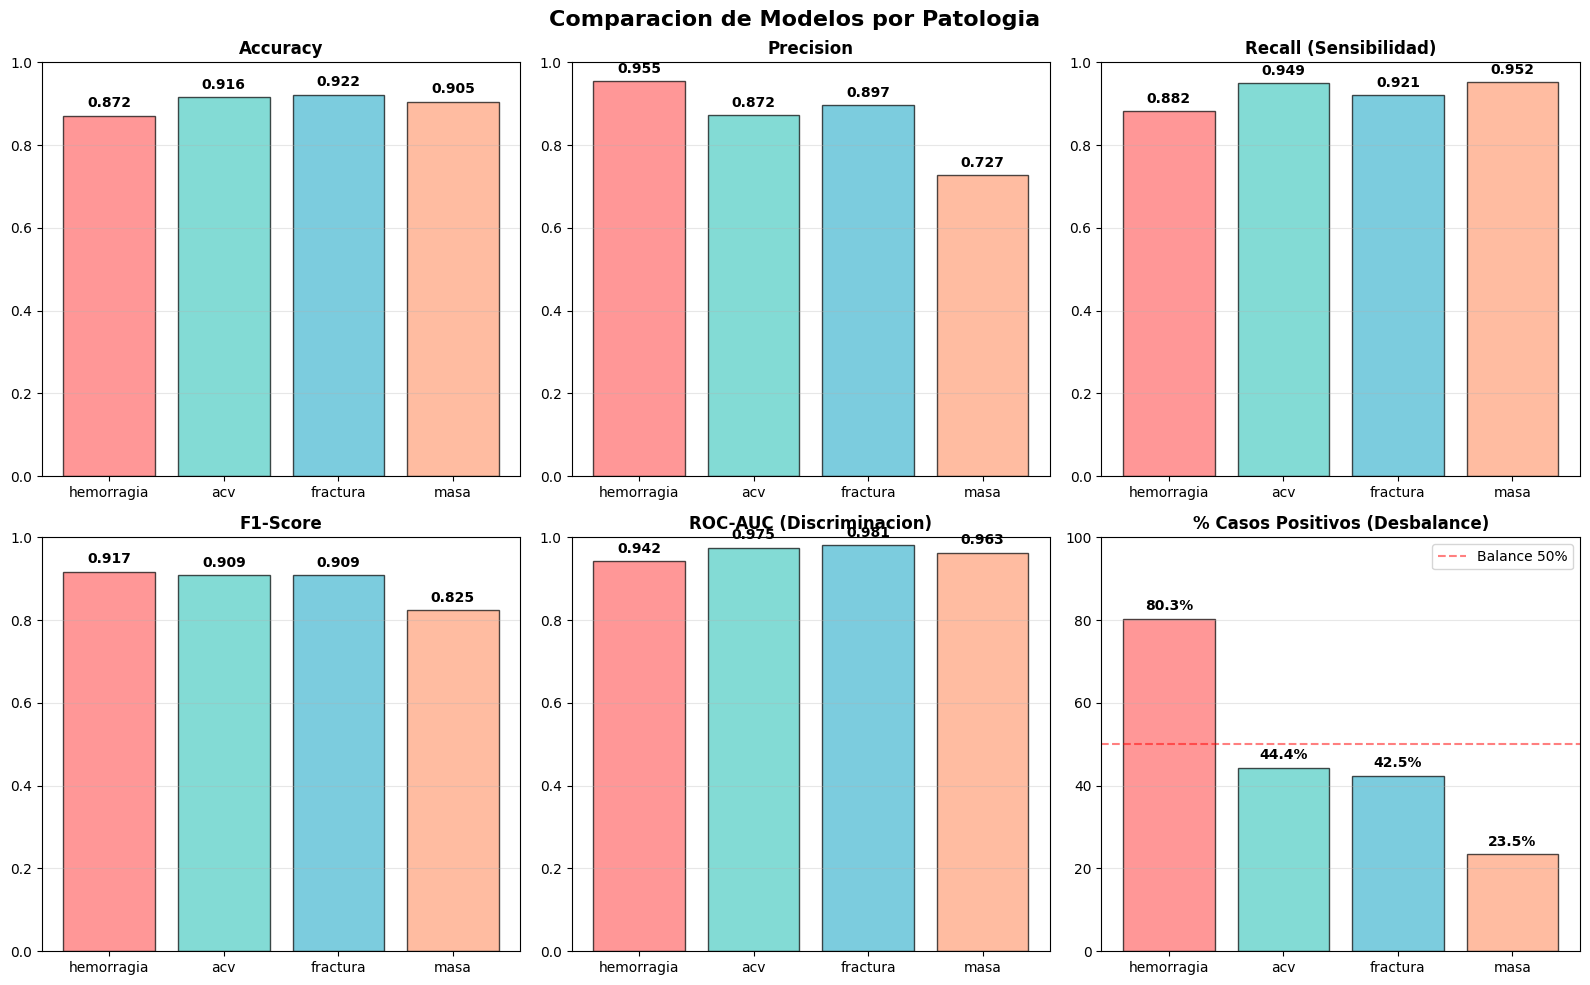


5. ANÁLISIS Y HALLAZGOS:

MEJOR DESEMPEÑO POR MÉTRICA:
  - Accuracy más alto:   fractura (0.9218)
  - Precision más alta:  hemorragia (0.9549)
  - Recall más alto:     masa (0.9524)
  - F1-Score más alto:   hemorragia (0.9170)
  - ROC-AUC más alto:    fractura (0.9808)

PATOLOGÍA MÁS DESAFIANTE:
  - HEMORRAGIA (ROC-AUC: 0.9419)

BALANCE DE CLASES:
  - hemorragia:  80.3% positivos (719/895)
  - acv       :  44.4% positivos (397/895)
  - fractura  :  42.5% positivos (380/895)
  - masa      :  23.5% positivos (210/895)


In [ ]:
# ENTRENAMIENTO DE TODOS LOS 4 MODELOS TENTATIVA Y COMPARACIÓN

print("ENTRENAMIENTO DE MODELOS PARA LAS 4 PATOLOGÍAS")

# 1. PREPARACIÓN: Vectorización una sola vez
print("\n1. PREPARACIÓN DE DATOS:")
print("-" * 80)

df = pd.read_excel('../../data_with_diagnostics_clean.xlsx')
X_text = df['Hallazgos'].astype(str)

# Stopwords en español
stopwords_es = [
    'de','la','y','el','en','del','con','se','las','los','por','para','al','lo','un','una','es','su','sus','que','a','o','sin','no','izquierdo','izquierda','derecha','derecho','mm'
]

# Vectorizar una sola vez (eficiente)
vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X_vectorized = vectorizer.fit_transform(X_text)
print(f"  - Vectorización completada: {X_vectorized.shape}")
print(f"  - Features extraídas: {X_vectorized.shape[1]}")

# 2. ENTRENAMIENTO DE LOS 4 MODELOS
print("\n2. ENTRENAMIENTO DE MODELOS:")
print("-" * 80)

patologias = ['hemorragia', 'acv', 'fractura', 'masa']
modelos = {}
resultados = {}

for patologia in patologias:
    print(f"\n  Entrenando modelo para: {patologia.upper()}")
    
    # Obtener etiqueta
    y = df[patologia].values
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    ratio = pos / len(y) * 100
    
    print(f"    - Clase positiva: {pos} ({ratio:.1f}%)")
    print(f"    - Clase negativa: {neg} ({100-ratio:.1f}%)")
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_vectorized, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y
    )
    
    # Entrenar modelo
    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    cm = confusion_matrix(y_test, y_pred)
    
    # Almacenar resultados
    modelos[patologia] = {
        'model': model,
        'vectorizer': vectorizer,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    resultados[patologia] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'TP': cm[1, 1],
        'TN': cm[0, 0],
        'FP': cm[0, 1],
        'FN': cm[1, 0],
        'Total_Positivos': pos,
        'Total_Negativos': neg
    }
    
    print(f"    - Accuracy:  {accuracy:.4f}")
    print(f"    - Precision: {precision:.4f}")
    print(f"    - Recall:    {recall:.4f}")
    print(f"    - F1-Score:  {f1:.4f}")
    print(f"    - ROC-AUC:   {roc_auc:.4f}")

# 3. TABLA COMPARATIVA
print("\n3. TABLA COMPARATIVA DE RESULTADOS:")
print("="*80)

# Crear DataFrame con resultados
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 
                                 'TP', 'TN', 'FP', 'FN', 'Total_Positivos', 'Total_Negativos']]

# Mostrar con formato
print("\n")
print(df_resultados.to_string())

# Guardar tabla
df_resultados.to_excel('../../modelos_comparacion.xlsx')
print("\nTabla guardada en: modelos_comparacion.xlsx")

# 4. VISUALIZACIÓN: Comparación de Métricas
print("\n4. VISUALIZACIONES:")
print("-" * 80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparacion de Modelos por Patologia', fontsize=16, fontweight='bold')

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Gráfico 1: Accuracy
axes[0, 0].bar(patologias, df_resultados['Accuracy'], color=colores, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Accuracy', fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_resultados['Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Gráfico 2: Precision
axes[0, 1].bar(patologias, df_resultados['Precision'], color=colores, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Precision', fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_resultados['Precision']):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Gráfico 3: Recall
axes[0, 2].bar(patologias, df_resultados['Recall'], color=colores, alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Recall (Sensibilidad)', fontweight='bold')
axes[0, 2].set_ylim([0, 1])
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_resultados['Recall']):
    axes[0, 2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Gráfico 4: F1-Score
axes[1, 0].bar(patologias, df_resultados['F1-Score'], color=colores, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('F1-Score', fontweight='bold')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_resultados['F1-Score']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Gráfico 5: ROC-AUC
axes[1, 1].bar(patologias, df_resultados['ROC-AUC'], color=colores, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('ROC-AUC (Discriminacion)', fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_resultados['ROC-AUC']):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Gráfico 6: Desbalance de clases
desbalance = df_resultados['Total_Positivos'] / (df_resultados['Total_Positivos'] + df_resultados['Total_Negativos']) * 100
axes[1, 2].bar(patologias, desbalance, color=colores, alpha=0.7, edgecolor='black')
axes[1, 2].set_title('% Casos Positivos (Desbalance)', fontweight='bold')
axes[1, 2].set_ylim([0, 100])
axes[1, 2].axhline(y=50, color='red', linestyle='--', label='Balance 50%', alpha=0.5)
axes[1, 2].grid(axis='y', alpha=0.3)
axes[1, 2].legend()
for i, v in enumerate(desbalance):
    axes[1, 2].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. RESUMEN ANALÍTICO
print("\n5. ANÁLISIS Y HALLAZGOS:")
print("="*80)

# Mejor modelo por métrica
print(f"\nMEJOR DESEMPEÑO POR MÉTRICA:")
print(f"  - Accuracy más alto:   {df_resultados['Accuracy'].idxmax()} ({df_resultados['Accuracy'].max():.4f})")
print(f"  - Precision más alta:  {df_resultados['Precision'].idxmax()} ({df_resultados['Precision'].max():.4f})")
print(f"  - Recall más alto:     {df_resultados['Recall'].idxmax()} ({df_resultados['Recall'].max():.4f})")
print(f"  - F1-Score más alto:   {df_resultados['F1-Score'].idxmax()} ({df_resultados['F1-Score'].max():.4f})")
print(f"  - ROC-AUC más alto:    {df_resultados['ROC-AUC'].idxmax()} ({df_resultados['ROC-AUC'].max():.4f})")

# Patología más desafiante
print(f"\nPATOLOGÍA MÁS DESAFIANTE:")
auc_min = df_resultados['ROC-AUC'].idxmin()
print(f"  - {auc_min.upper()} (ROC-AUC: {df_resultados['ROC-AUC'].min():.4f})")

# Patología más balanceada
print(f"\nBALANCE DE CLASES:")
for pat in patologias:
    pos = resultados[pat]['Total_Positivos']
    total = pos + resultados[pat]['Total_Negativos']
    ratio = pos / total * 100
    print(f"  - {pat:10s}: {ratio:5.1f}% positivos ({pos:3d}/{total})")

ANALISIS COMPARATIVO: Recall, Precision, F1-Score por Patologia

1. RANKING POR RECALL (Detecta casos positivos reales):
--------------------------------------------------------------------------------
 Patologia   Recall
      masa 0.952381
       acv 0.949367
  fractura 0.921053
hemorragia 0.881944

2. RANKING POR PRECISION (Predicciones correctas):
--------------------------------------------------------------------------------
 Patologia  Precision
hemorragia   0.954887
  fractura   0.897436
       acv   0.872093
      masa   0.727273

3. RANKING POR F1-SCORE (Balance Precision-Recall):
--------------------------------------------------------------------------------
 Patologia  F1-Score
hemorragia  0.916968
       acv  0.909091
  fractura  0.909091
      masa  0.824742

4. TABLA COMPLETA DE METRICAS:
--------------------------------------------------------------------------------
 Patologia   Recall  Precision  F1-Score
hemorragia 0.881944   0.954887  0.916968
       acv 0.949367  

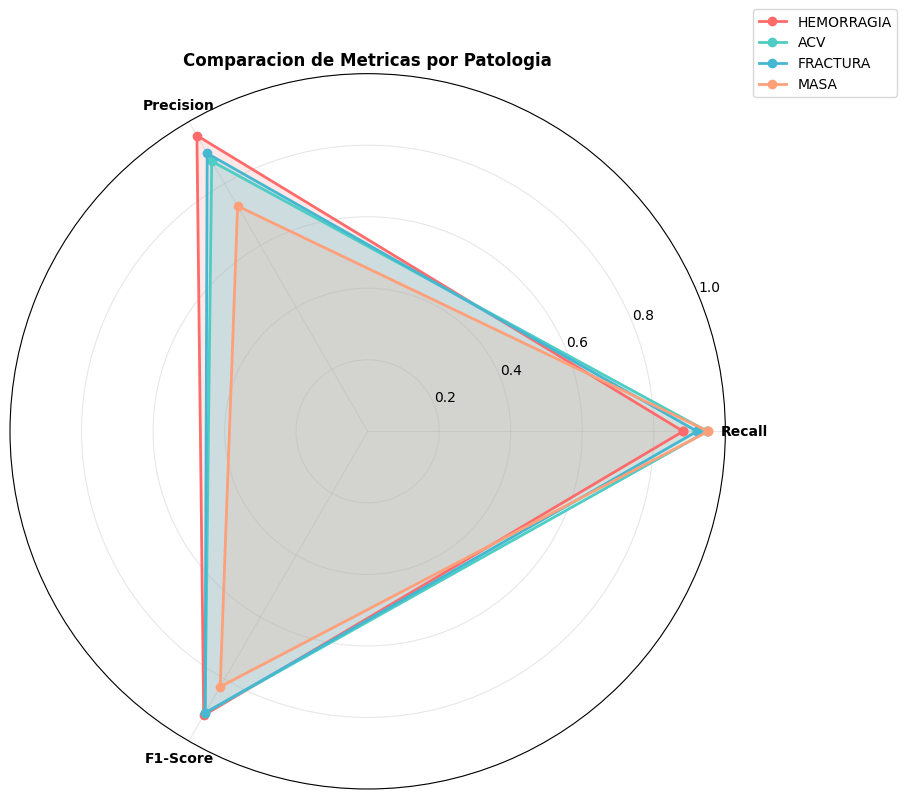

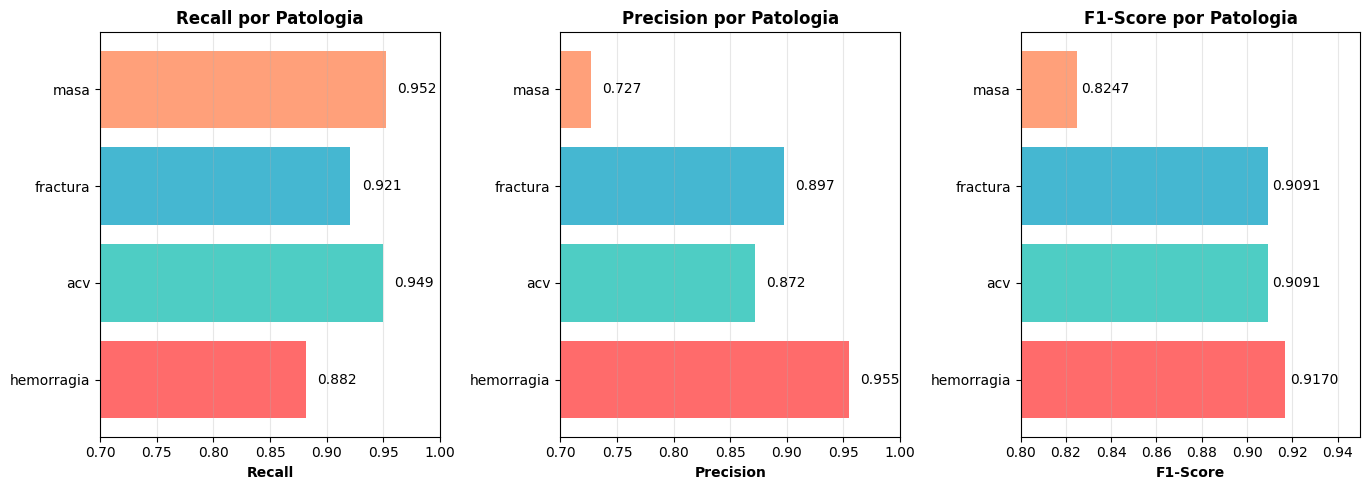

In [ ]:
# ============================================================================
# ANALISIS COMPARATIVO: Recall, Precision, F1 por Patologia
# ============================================================================

comparacion_datos = {
    'Patologia': ['hemorragia', 'acv', 'fractura', 'masa'],
    'Recall': [0.881944, 0.949367, 0.921053, 0.952381],
    'Precision': [0.954887, 0.872093, 0.897436, 0.727273],
    'F1-Score': [0.916968, 0.909091, 0.909091, 0.824742]
}

df_comp = pd.DataFrame(comparacion_datos)

print("="*80)
print("ANALISIS COMPARATIVO: Recall, Precision, F1-Score por Patologia")
print("="*80)

print("\n1. RANKING POR RECALL (Detecta casos positivos reales):")
print("-"*80)
df_recall = df_comp[['Patologia', 'Recall']].sort_values('Recall', ascending=False)
print(df_recall.to_string(index=False))

print("\n2. RANKING POR PRECISION (Predicciones correctas):")
print("-"*80)
df_prec = df_comp[['Patologia', 'Precision']].sort_values('Precision', ascending=False)
print(df_prec.to_string(index=False))

print("\n3. RANKING POR F1-SCORE (Balance Precision-Recall):")
print("-"*80)
df_f1 = df_comp[['Patologia', 'F1-Score']].sort_values('F1-Score', ascending=False)
print(df_f1.to_string(index=False))

print("\n4. TABLA COMPLETA DE METRICAS:")
print("-"*80)
print(df_comp.to_string(index=False))

print("\n5. HALLAZGOS PRINCIPALES:")
print("-"*80)
print(f"Mejor Recall (detecta más casos):   {df_recall.iloc[0]['Patologia']:12s} {df_recall.iloc[0]['Recall']:.2%}")
print(f"Mejor Precision (menos falsos):     {df_prec.iloc[0]['Patologia']:12s} {df_prec.iloc[0]['Precision']:.2%}")
print(f"Mejor F1-Score (mejor balance):     {df_f1.iloc[0]['Patologia']:12s} {df_f1.iloc[0]['F1-Score']:.4f}")

print("\nInterpretacion por patologia:")
print("-"*80)
print("HEMORRAGIA: Mejor precision (95.5%) - pocas falsas alarmas")
print("  Recall: 88.2% (pierde 11.8% casos) - requiere revision adicional")
print()
print("ACV: Excelente recall (94.9%) - detecta casi todos los casos")
print("  Precision: 87.2% - mas falsos positivos aceptables")
print()
print("FRACTURA: Balance moderado (92.1% recall, 89.7% precision)")
print("  Modelo mas equilibrado para uso general")
print()
print("MASA: Mejor recall (95.2%) - detecta casi todos los casos")
print("  Precision: 72.7% - muchas falsas alarmas (no usar solo)")

# VISUALIZACION: Radar Chart
print("\n\n6. GRAFICO COMPARATIVO (Radar Chart):")
print("-"*80)

categories = ['Recall', 'Precision', 'F1-Score']
patologias_list = ['hemorragia', 'acv', 'fractura', 'masa']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
colores = {'hemorragia': '#FF6B6B', 'acv': '#4ECDC4', 'fractura': '#45B7D1', 'masa': '#FFA07A'}

for idx, pat in enumerate(patologias_list):
    values = [df_comp.loc[idx, 'Recall'], df_comp.loc[idx, 'Precision'], df_comp.loc[idx, 'F1-Score']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=pat.upper(), color=colores[pat])
    ax.fill(angles, values, alpha=0.15, color=colores[pat])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.title('Comparacion de Metricas por Patologia', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# VISUALIZACION: Barras comparativas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].barh(df_comp['Patologia'], df_comp['Recall'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_xlabel('Recall', fontweight='bold')
axes[0].set_xlim([0.7, 1.0])
axes[0].set_title('Recall por Patologia', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_comp['Recall']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

axes[1].barh(df_comp['Patologia'], df_comp['Precision'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1].set_xlabel('Precision', fontweight='bold')
axes[1].set_xlim([0.7, 1.0])
axes[1].set_title('Precision por Patologia', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_comp['Precision']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

axes[2].barh(df_comp['Patologia'], df_comp['F1-Score'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[2].set_xlabel('F1-Score', fontweight='bold')
axes[2].set_xlim([0.8, 0.95])
axes[2].set_title('F1-Score por Patologia', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_comp['F1-Score']):
    axes[2].text(v + 0.002, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()



El análisis comparativo demuestra que el modelo no optimiza una única métrica de forma global, presenta perfiles de  desempeño diferenciados por patología.